<a href="https://colab.research.google.com/github/xl4357/MSSP6070/blob/main/assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
from google.colab import files

uploaded = files.upload()

Saving data_academic_performance.xlsx to data_academic_performance (1).xlsx


In [48]:
import pandas as pd
df = pd.read_excel('data_academic_performance.xlsx')

In [50]:
df.shape

(12411, 45)

average

In [93]:
df['Score_MEAN'] = df[
    ['QR_PRO', 'CR_PRO', 'CC_PRO', 'WC_PRO', 'ENG_PRO', 'FEP_PRO', 'G_SC']
].mean(axis=1)

df['Score_MEAN']

,Score_MEAN
0,109.714286
1,111.428571
2,46.714286
3,85.428571
4,120.571429
...,...
12406,102.142857
12407,53.428571
12408,117.714286
12409,72.571429


Female and Male

In [94]:
gender_stats = df.groupby('GENDER')['G_SC'].agg(
    ['count', 'mean', 'median', 'std']
)

gender_stats

,count,mean,median,std
GENDER,,,,
F,5043,161.278207,162.0,22.332939
M,7368,163.690825,164.0,23.582616


In [95]:
female_mean = gender_stats.loc['F', 'mean']
male_mean = gender_stats.loc['M', 'mean']

difference = female_mean - male_mean

print("Female mean:", female_mean)
print("Male mean:", male_mean)
print("Difference:", difference)

Female mean: 161.2782074162205
Male mean: 163.69082519001086
Difference: -2.4126177737903447


Female students had an average Score 1.6 points lower than male students.

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

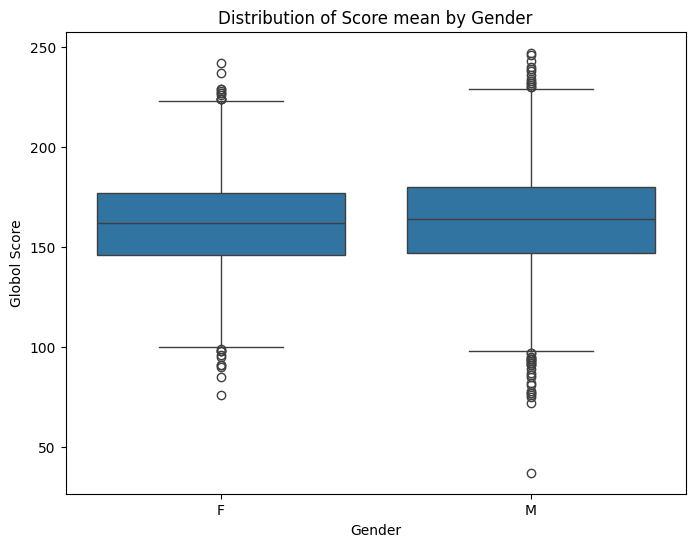

In [97]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='GENDER',
    y='G_SC'
)

plt.title('Distribution of Score mean by Gender')
plt.xlabel('Gender')
plt.ylabel('Globol Score')

plt.show()

median 25 75 percentile,,dispersion outlier

specific competencies

In [64]:
pro_scores = [
    'QR_PRO',
    'CR_PRO',
    'CC_PRO',
    'WC_PRO',
    'ENG_PRO',
    'FEP_PRO',
    'G_SC'
]

gender_pro_stats = df.groupby('GENDER')[pro_scores].mean()

gender_pro_stats

,QR_PRO,CR_PRO,CC_PRO,WC_PRO,ENG_PRO,FEP_PRO,G_SC
GENDER,,,,,,,
F,71.892723,61.338687,58.573865,56.618084,66.532421,145.302796,161.278207
M,81.198561,62.788409,59.606270,51.708469,68.159473,145.595548,163.690825


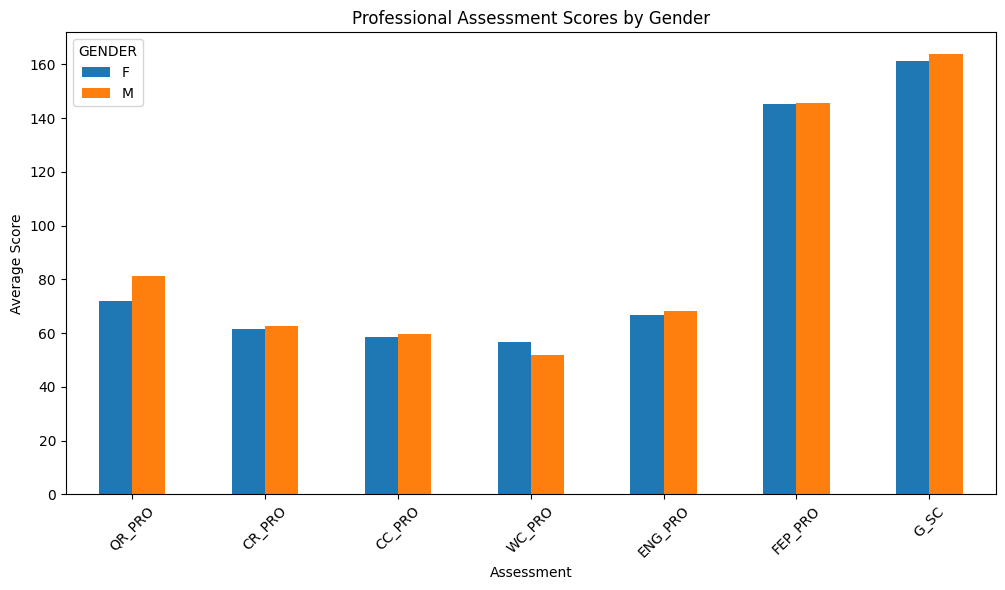

In [99]:
gender_pro_stats.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Professional Assessment Scores by Gender')
plt.xlabel('Assessment')
plt.ylabel('Average Score')

plt.xticks(rotation=45)

plt.show()

Statistical Test

statistically significant difference？

t-test

In [100]:
from scipy.stats import ttest_ind

female = df[df['GENDER'] == 'F']['G_SC']
male = df[df['GENDER'] == 'M']['G_SC']

t_stat, p_value = ttest_ind(
    female,
    male,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -5.777471574966612
p-value: 7.785030938251425e-09


p<0.05

There is a statistically significant difference in Global Score between female and male students.

Does parental education influence outcomes, and if so, how much?

In [69]:
df.groupby('EDU_FATHER')['Score_MEAN'].mean()

,Score_MEAN
EDU_FATHER,
0,83.536719
Complete Secundary,86.380483
Complete primary,83.464632
Complete professional education,93.991995
Complete technique or technology,91.032424
Incomplete Professional Education,93.452437
Incomplete Secundary,84.459474
Incomplete primary,83.896793
Incomplete technical or technological,89.320268


In [70]:
df.groupby('EDU_MOTHER')['Score_MEAN'].mean()

,Score_MEAN
EDU_MOTHER,
0,83.235641
Complete Secundary,86.173581
Complete primary,83.709076
Complete professional education,94.788820
Complete technique or technology,90.436503
Incomplete Professional Education,92.994024
Incomplete Secundary,83.909226
Incomplete primary,83.387642
Incomplete technical or technological,89.289066


In [102]:
father_difference = father_edu.max() - father_edu.min()
mother_difference = mother_edu.max() - mother_edu.min()

print("Father education difference:", father_difference)
print("Mother education difference:", mother_difference)

Father education difference: 17.941029164562792
Mother education difference: 19.690259855195848


<Axes: title={'center': "Average Score by Parents' Education"}, xlabel='Education Level', ylabel='Mean Score'>

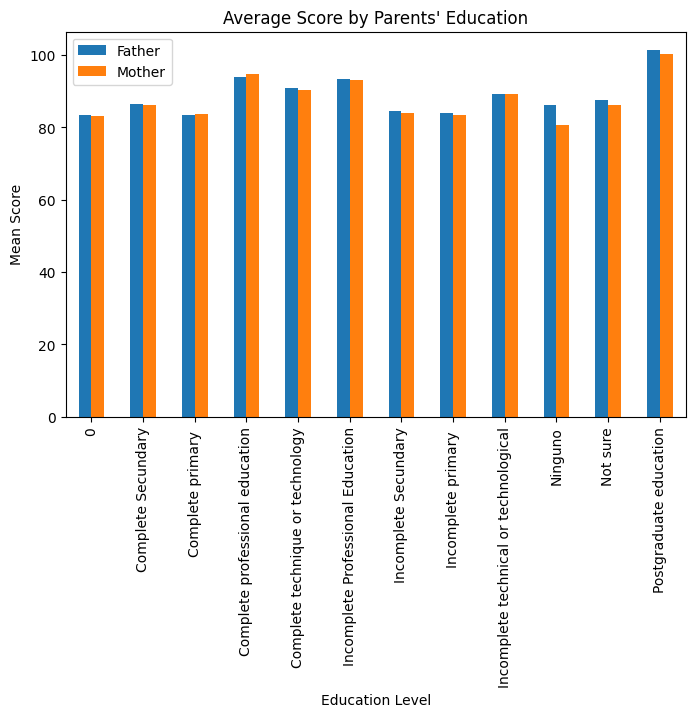

In [103]:
father_mean = df.groupby('EDU_FATHER')['Score_MEAN'].mean()
mother_mean = df.groupby('EDU_MOTHER')['Score_MEAN'].mean()

parent_edu = pd.DataFrame({
    "Father": father_mean,
    "Mother": mother_mean
})

parent_edu.plot(
    kind='bar',
    figsize=(8, 5),
    title="Average Score by Parents' Education",
    xlabel="Education Level",
    ylabel="Mean Score"
)

stratums

In [87]:
df.groupby('STRATUM')['Score_MEAN'].mean()

,Score_MEAN
STRATUM,
0,81.540816
Stratum 1,81.507063
Stratum 2,86.024288
Stratum 3,90.290164
Stratum 4,97.884574
Stratum 5,102.306477
Stratum 6,104.988302


In [88]:
stratum_mean = df.groupby('STRATUM')['Score_MEAN'].mean()

stratum_difference = stratum_mean.max() - stratum_mean.min()

print(stratum_mean)
print("Difference between highest and lowest stratums:",
      stratum_difference)

STRATUM
0             81.540816
Stratum 1     81.507063
Stratum 2     86.024288
Stratum 3     90.290164
Stratum 4     97.884574
Stratum 5    102.306477
Stratum 6    104.988302
Name: Score_MEAN, dtype: float64
Difference between highest and lowest stratums: 23.4812385749361


In [89]:
df.groupby('STRATUM')['Score_MEAN'].mean()

,Score_MEAN
STRATUM,
0,81.540816
Stratum 1,81.507063
Stratum 2,86.024288
Stratum 3,90.290164
Stratum 4,97.884574
Stratum 5,102.306477
Stratum 6,104.988302


<Axes: title={'center': 'Average Score by Stratum'}, xlabel='Stratum', ylabel='Mean Score'>

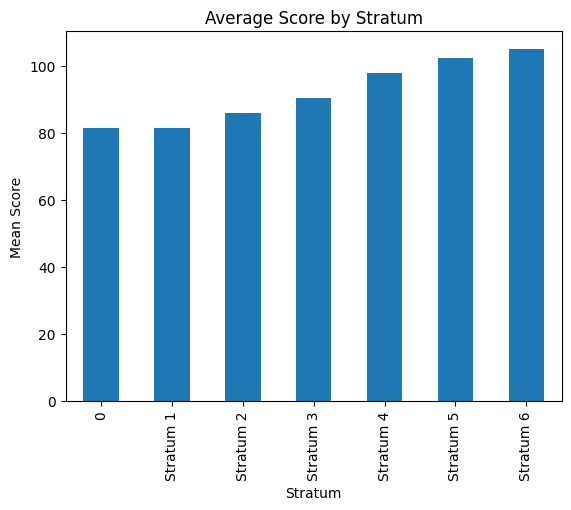

In [101]:
stratum_mean = df.groupby('STRATUM')['Score_MEAN'].mean()

stratum_mean.plot(
    kind='bar',
    title="Average Score by Stratum",
    xlabel="Stratum",
    ylabel="Mean Score"
)

In [104]:
best_stratum = stratum_mean.idxmax()
best_score = stratum_mean.max()

worst_stratum = stratum_mean.idxmin()
worst_score = stratum_mean.min()

print("Best group:", best_stratum)
print("Best average score:", best_score)
print("Lowest group:", worst_stratum)
print("Lowest average score:", worst_score)

Best group: Stratum 6
Best average score: 104.9883020205601
Lowest group: Stratum 1
Lowest average score: 81.507063445624


In [105]:
stratum_difference = stratum_mean.max() - stratum_mean.min()

print("Difference between highest and lowest groups:", stratum_difference)

Difference between highest and lowest groups: 23.4812385749361


In [107]:
stratum_sd = df.groupby('STRATUM')['Score_MEAN'].std()

stratum_sd

stratum_summary = df.groupby('STRATUM')['Score_MEAN'].agg(
    ['mean', 'std', 'count']
)

stratum_summary

,mean,std,count
STRATUM,,,
0,81.540816,18.839834,14
Stratum 1,81.507063,19.934977,1709
Stratum 2,86.024288,19.457818,4029
Stratum 3,90.290164,18.907605,4045
Stratum 4,97.884574,18.241943,1578
Stratum 5,102.306477,17.390959,633
Stratum 6,104.988302,17.793827,403


Private school vs Public School

In [109]:
school_mean = df.groupby('SCHOOL_NAT')['Score_MEAN'].mean()

school_mean

,Score_MEAN
SCHOOL_NAT,
PRIVATE,94.086149
PUBLIC,84.863032


In [111]:
school_difference = school_mean.max() - school_mean.min()

school_difference

9.223117384202737

<Axes: title={'center': 'Average Academic Performance by High School Type'}, xlabel='High School Type', ylabel='Average Score'>

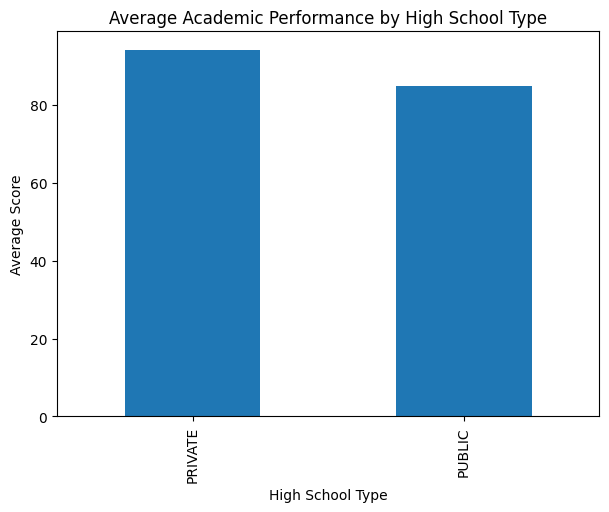

In [112]:
school_mean.plot(
    kind='bar',
    figsize=(7, 5),
    title='Average Academic Performance by High School Type',
    xlabel='High School Type',
    ylabel='Average Score'
)